# Análise de Dados de Comportamento de Usuários em Dispositivos Móveis

Neste projeto, será realizada uma análise exploratória de dados com o objetivo de investigar padrões de comportamento dos usuários em dispositivos móveis. Para isso, serão utilizadas bibliotecas do Python voltadas para manipulação, visualização e análise de dados.

## Importação das bibliotecas

Inicialmente, foram importadas as bibliotecas necessárias para a manipulação dos dados e construção das visualizações gráficas ao longo da análise.

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np 
import seaborn as sns

## Configuração visual

Para manter um padrão estético ao longo do projeto, foram definidas configurações visuais para os gráficos, como fonte, cores, tamanhos de títulos, rótulos e estilo geral das visualizações.

Além disso, foi criada uma paleta de cores personalizada para garantir maior consistência visual entre os gráficos apresentados.

In [22]:
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

# Configurando gráfico
plt.rcParams.update({
    # Fonte
    'font.family': 'DejaVu Sans',

    # Cor geral do texto
    'text.color':'#333333', 
    'axes.labelcolor': '#4a4a4a',
    'xtick.color': '#6a6a6a',
    'ytick.color': '#6a6a6a',

    # Titulo Geral
    'figure.titlesize': 18,
    'figure.titleweight': 'medium',

    # Titulos dos subplots
    'axes.titlesize': 11,
    'axes.titleweight': 'regular',

    # Labels
    'axes.labelsize': 10,

    # Texto Geral
    'font.size': 11,

    # Remover bordas pesadas
    'axes.edgecolor': '#DDDDDD',

    # Grid suave
    'grid.color':  '#EEEEEE'

})

Além disso, foi criada uma paleta de cores personalizada para garantir maior consistência visual entre os gráficos apresentados.

In [23]:
paleta_cores = [
    '#5F9EA0',  # Verde-azulado suave (cadet blue)
    '#E9967A',  # Salmão suave (dark salmon)
    '#B0C4DE',  # Azul claro (light steel blue)
    '#DAA520',  # Dourado suave (goldenrod)
    '#9ACD32',  # Verde amarelado suave (yellow green)
    '#CD853F',  # Marrom alaranjado suave (peru)
    '#8FBC8F',  # Verde acinzentado (dark sea green)
    '#BC8F8F',  # Rosa acinzentado (rosy brown)
    '#A9A9A9',  # Cinza médio (dark gray)
    '#B0E0E6',  # Azul bem claro (powder blue)
]


## Carregamento da base de dados

Em seguida, foi realizada a importação do conjunto de dados contendo informações sobre o comportamento de usuários em dispositivos móveis. Também foi feito um ajuste no nome das colunas, padronizando os textos em letras minúsculas e removendo espaços extras, o que facilita a manipulação posterior dos dados.

In [24]:
df = pd.read_csv('user_behavior_dataset.csv', sep = ',', encoding = "ISO-8859-1")
df.columns = df.columns.str.lower().str.strip()
df.head()

,user id,device model,operating system,app usage time (min/day),screen on time (hours/day),battery drain (mah/day),number of apps installed,data usage (mb/day),age,gender,user behavior class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


Após o carregamento, foi feita uma visualização inicial da base para verificar a estrutura do dataset e as variáveis disponíveis para análise.

## Questão 1 — Análise univariada das variáveis categóricas

Nesta etapa, foi realizada uma análise univariada das variáveis categóricas **sistema operacional** e **gênero**, com o objetivo de identificar como os usuários estão distribuídos em cada uma dessas categorias.

Para isso, foram calculados os percentuais de cada sistema operacional presente no conjunto de dados, bem como os percentuais de cada gênero, e os resultados foram representados em gráficos de barras para facilitar a visualização e a comparação entre as categorias.

(0.0, 57.2)

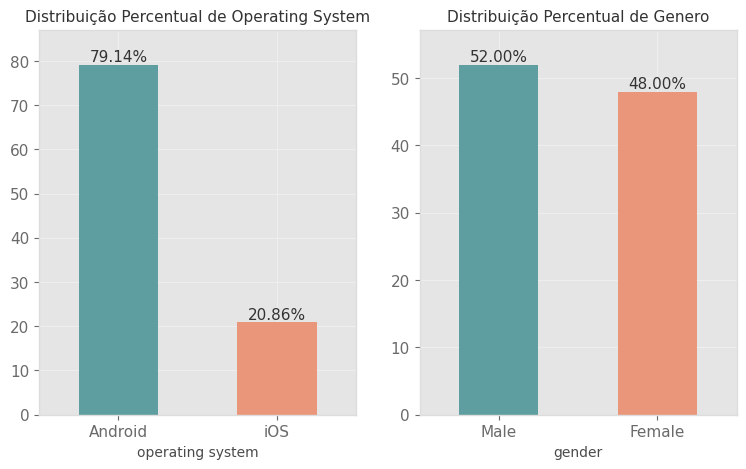

In [25]:
op_system_dist = df['operating system'].value_counts(normalize=True) * 100
gender_dist = df['gender'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1,2, figsize = (9, 5))

ax[0] = op_system_dist.plot(
    kind = 'bar',
    color = paleta_cores,
    ax = ax[0]
)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt = '%1.2f%%')

ax[0].set_title('Distribuição Percentual de Operating System')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 0)
ax[0].set_ylim(top = op_system_dist.max() * 1.1)
ax[1] = gender_dist.plot(
    kind = 'bar',
    color = paleta_cores,
    ax = ax[1]
)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt = '%1.2f%%')
ax[1].set_title('Distribuição Percentual de Genero')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 0)
ax[1].set_ylim(top = gender_dist.max() * 1.1 )

A partir dos gráficos, é possível observar a distribuição percentual dos usuários por **sistema operacional** e por **gênero** no conjunto de dados. Essa análise inicial é importante para compreender a composição da base e identificar se existe predominância de alguma categoria.

Essas informações servem como ponto de partida para as próximas etapas da análise, especialmente nas comparações entre grupos, como sistema operacional, gênero e comportamento de uso.

## Questão 2 — Análise univariada das variáveis numéricas

Após a análise das variáveis categóricas, a próxima etapa consiste em investigar a distribuição de algumas variáveis numéricas do conjunto de dados, como **tempo de uso de aplicativos**, **tempo de tela**, **número de aplicativos instalados** e **idade** dos usuários.

Para isso, foram construídos histogramas, que permitem visualizar a frequência dos valores em diferentes intervalos e ajudam a identificar padrões como concentração de dados, dispersão e possíveis assimetrias nas distribuições.

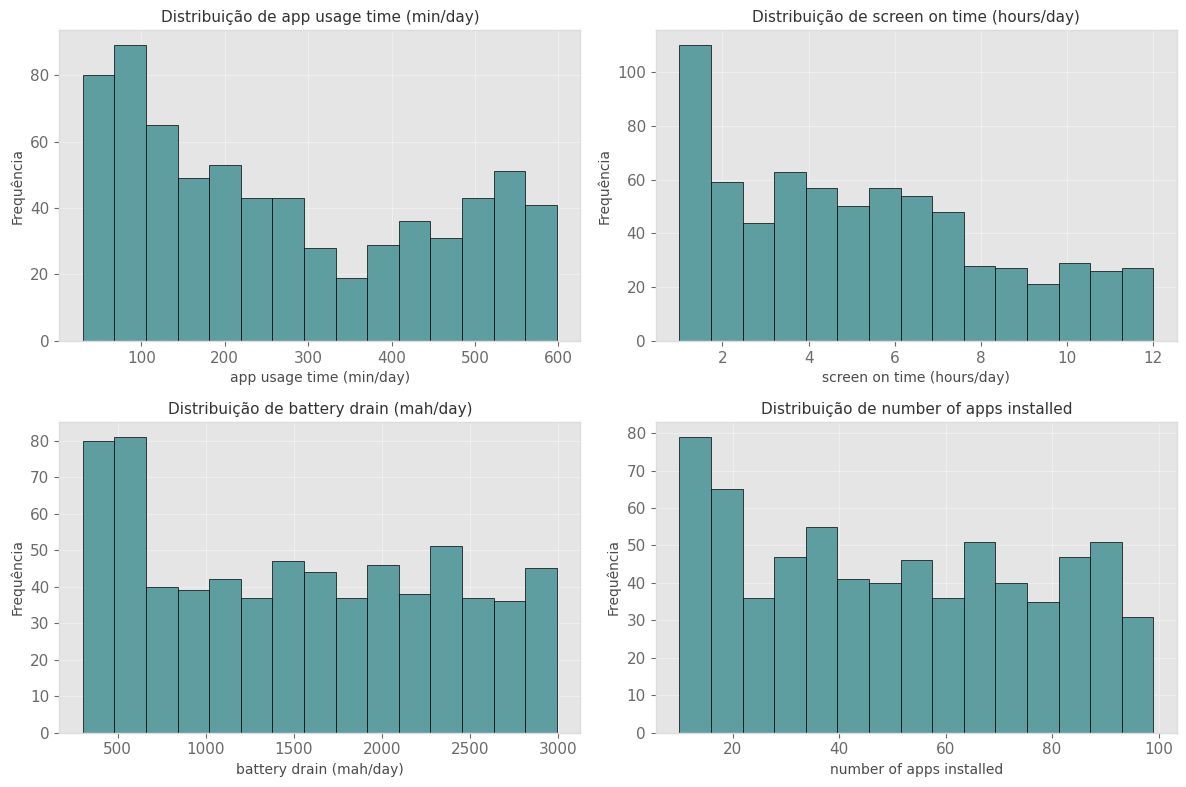

In [45]:
cols_numericas = df.select_dtypes(include = 'number').drop(columns=['user id', 'user behavior class'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), cols_numericas):
    ax.hist(df[col], bins=15, color = paleta_cores[0], edgecolor='black')
    ax.set_title(f'Distribuição de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

Por meio dos histogramas, é possível observar como os valores das variáveis numéricas se distribuem no conjunto de dados. Esse tipo de visualização ajuda a identificar se os dados estão mais concentrados em determinadas faixas, se apresentam maior dispersão ou se possuem comportamento mais uniforme.

Essa análise é importante para compreender melhor o perfil dos usuários e serve de base para etapas posteriores, nas quais essas variáveis serão comparadas entre grupos e relacionadas com outros fatores do dataset.

## Questão 3 — Quantidade de observações por classe de comportamento

Dando continuidade à análise univariada, nesta etapa foi verificada a quantidade de observações existentes em cada **classe de comportamento** presente no conjunto de dados.

Para isso, foi construída uma visualização em gráfico de barras, permitindo comparar o número de usuários em cada categoria e identificar se as classes estão distribuídas de forma equilibrada ou se existe maior concentração em algum grupo específico.

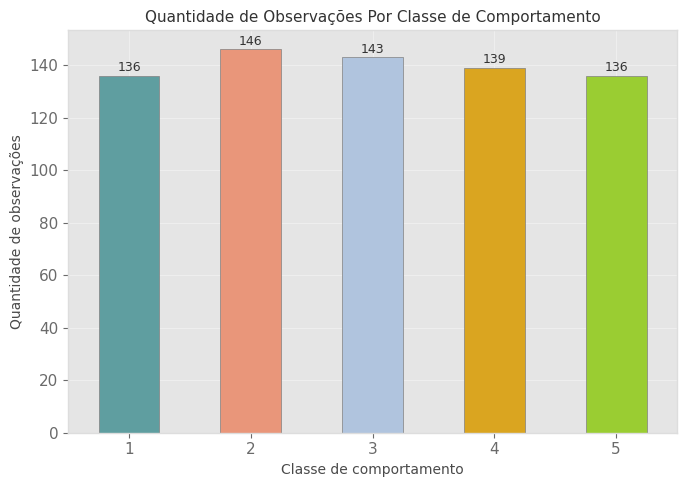

In [27]:
contagem_classe = df['user behavior class'].value_counts().sort_index()

fig, ax = plt.subplots(figsize = (7, 5))

ax = contagem_classe.plot(
    kind = 'bar',
    color = paleta_cores,
    edgecolor = 'gray'
)
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 9, padding = 1)
ax.set_title('Quantidade de Observações Por Classe de Comportamento')
ax.set_xlabel('Classe de comportamento')
ax.set_ylabel('Quantidade de observações')
ax.set_xticklabels(ax.get_xticklabels(), rotation = 0)
plt.tight_layout()
plt.show()

A partir do gráfico, é possível observar como os usuários estão distribuídos entre as classes de comportamento disponíveis no dataset. Como as quantidades são semelhantes, isso sugere uma base mais equilibrada entre as categorias. Por outro lado, caso existisse predominância de alguma classe, essa característica deve ser considerada na interpretação das análises seguintes.

Assim, essa etapa contribui para uma compreensão inicial da estrutura da variável **classe de comportamento**, que será utilizada novamente em análises posteriores.

## Questão 4 — Comparação do consumo de bateria entre Android e iOS

Nesta etapa, o objetivo é comparar o comportamento da variável **consumo de bateria por dia** entre dispositivos com sistema operacional **Android** e **iOS**.

Para isso, foram construídos histogramas separados para cada sistema operacional e também um gráfico com as distribuições sobrepostas, facilitando a comparação visual entre os dois grupos. Esse tipo de análise permite verificar se existe maior concentração de valores em determinadas faixas de consumo e se há diferenças perceptíveis no padrão de uso entre Android e iOS.

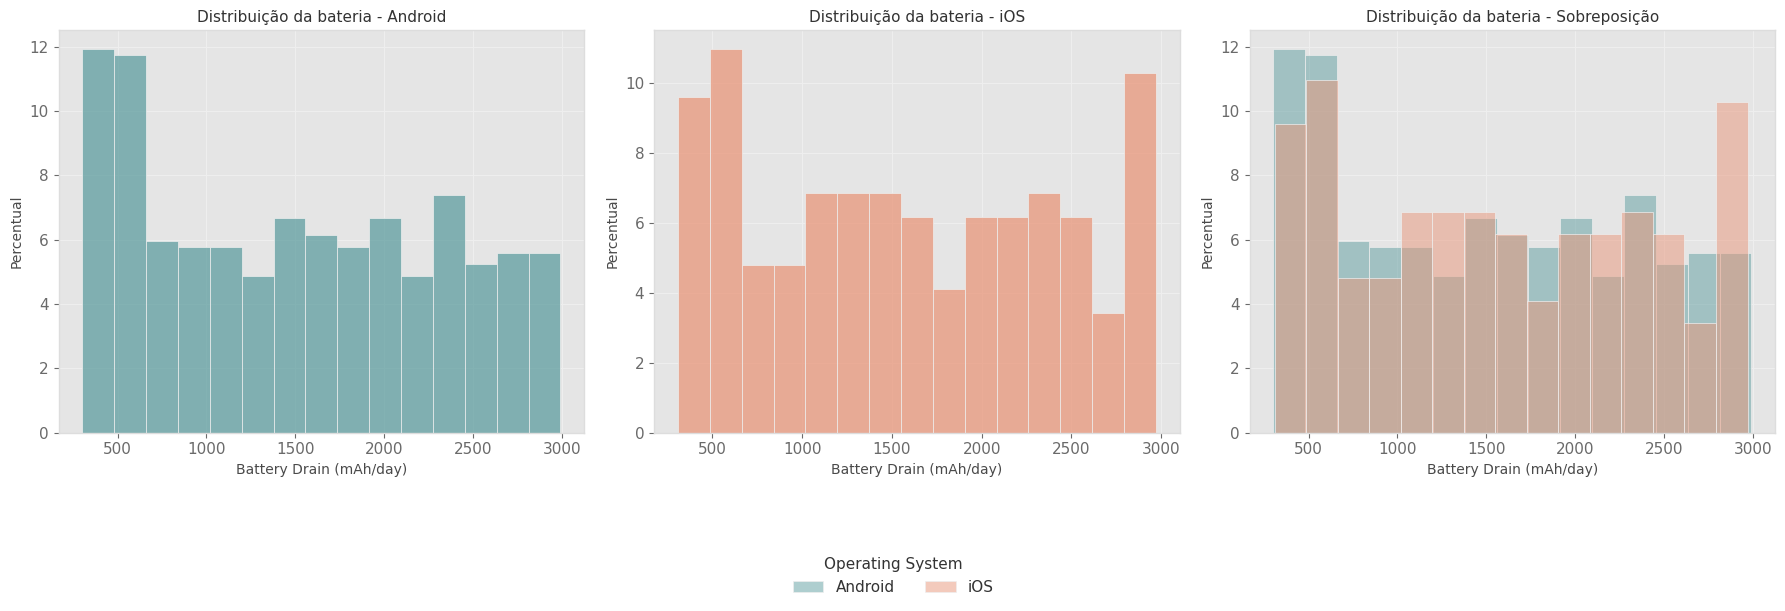

In [28]:
android = df[df['operating system'] == 'Android']['battery drain (mah/day)']
ios = df[df['operating system'] == 'iOS']['battery drain (mah/day)']

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=android, bins=15, stat='percent', color=paleta_cores[0], ax=ax[0])
ax[0].set_title('Distribuição da bateria - Android')
ax[0].set_xlabel('Battery Drain (mAh/day)')
ax[0].set_ylabel('Percentual')

sns.histplot(data=ios, bins=15, stat='percent', color=paleta_cores[1], ax=ax[1])
ax[1].set_title('Distribuição da bateria - iOS')
ax[1].set_xlabel('Battery Drain (mAh/day)')
ax[1].set_ylabel('Percentual')

sns.histplot(data=android, bins=15, stat='percent', color=paleta_cores[0], alpha=0.5, label='Android', ax=ax[2])
sns.histplot(data=ios, bins=15, stat='percent', color=paleta_cores[1], alpha=0.5, label='iOS', ax=ax[2])
ax[2].set_title('Distribuição da bateria - Sobreposição')
ax[2].set_xlabel('Battery Drain (mAh/day)')
ax[2].set_ylabel('Percentual')
fig.legend(
    title='Operating System',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.10),
    ncol=2,
    frameon = False)

plt.tight_layout()
plt.show()

Os histogramas indicam que **Android** e **iOS** apresentam distribuições relativamente semelhantes no consumo diário de bateria, com valores espalhados por diferentes faixas ao longo do eixo horizontal. Em ambos os sistemas, observa-se presença de dispositivos com consumo mais baixo e também com consumo mais elevado, o que sugere certa variabilidade no padrão de uso.

No entanto, a sobreposição das distribuições mostra alguns indícios de diferença entre os grupos. O **iOS** parece apresentar maior concentração em faixas mais altas de consumo, especialmente próximo aos valores mais elevados do gráfico, enquanto o **Android** aparenta uma distribuição um pouco mais espalhada ao longo do intervalo observado.

Ainda assim, a diferença visual entre os sistemas não parece ser tão acentuada a ponto de permitir uma conclusão definitiva apenas pelos histogramas. Por isso, essa análise gráfica é útil como evidência inicial, mas pode ser complementada por outras medidas descritivas, como mediana, quartis e boxplots, para uma comparação mais robusta entre Android e iOS.

## Questão 5 — Relação entre tempo de tela e consumo de bateria

Nesta etapa, foi investigada a relação entre o **tempo de tela ligada por dia** e o **consumo diário de bateria** dos dispositivos.

Como ambas são variáveis numéricas, a análise foi realizada por meio de duas abordagens complementares: o **coeficiente de correlação de Pearson**, que mede a intensidade da relação linear entre as variáveis, e o **gráfico de dispersão**, que permite observar visualmente o comportamento dos dados.

Além disso, os pontos foram diferenciados por **sistema operacional**, para verificar se a relação entre tempo de tela e consumo de bateria apresenta algum padrão distinto entre dispositivos **Android** e **iOS**.

In [29]:
correlacao = df['screen on time (hours/day)'].corr(
    df['battery drain (mah/day)'],
    method='pearson'
)
correlacao

np.float64(0.9489831361266119)

O coeficiente de correlação de Pearson entre o **tempo de tela ligada por dia** e o **consumo diário de bateria** foi de **0,94**, o que indica uma **relação linear positiva muito forte** entre essas variáveis. Em termos práticos, isso sugere que usuários com maior tempo de tela tendem, de forma consistente, a apresentar maior consumo de bateria ao longo do dia.

Essa conclusão também é reforçada pelo gráfico de dispersão, que apresenta uma tendência ascendente bem definida. Quando os pontos são separados por sistema operacional, nota-se que **Android** e **iOS** seguem um padrão visual bastante semelhante, sem diferenças muito marcantes na relação entre tempo de tela e consumo de bateria.

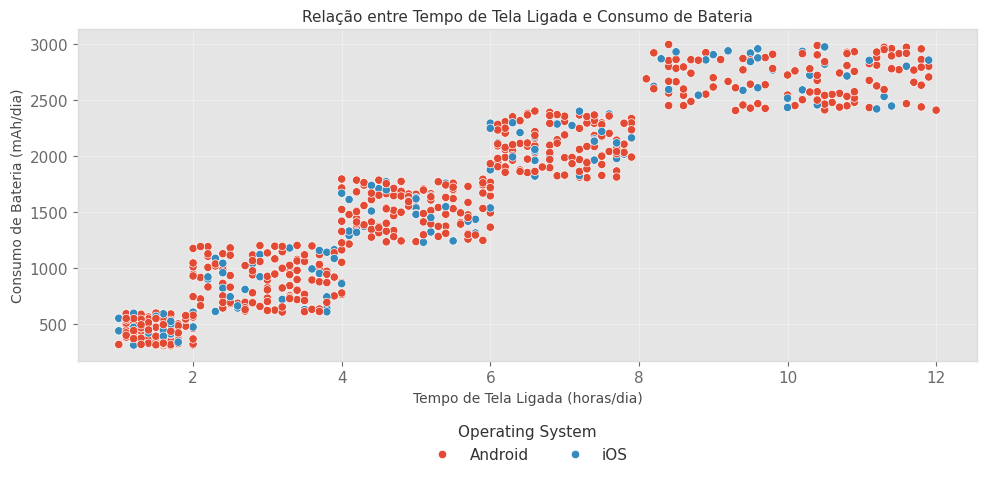

In [30]:
fig, ax = plt.subplots(figsize = (10, 5))

sns.scatterplot(data = df, x = 'screen on time (hours/day)', y = 'battery drain (mah/day)', color = paleta_cores[0], hue='operating system',)
ax.set_title('Relação entre Tempo de Tela Ligada e Consumo de Bateria')
ax.set_xlabel('Tempo de Tela Ligada (horas/dia)')
ax.set_ylabel('Consumo de Bateria (mAh/dia)')
ax.legend(
    title='Operating System',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon = False)
plt.tight_layout()

A análise do gráfico de dispersão mostra uma relação positiva entre o tempo de tela ligada e o consumo de bateria. Em geral, usuários com maior tempo de tela apresentam também maior gasto diário de bateria.

Quando os dados são separados por sistema operacional, observa-se que **Android** e **iOS** seguem um comportamento bastante parecido, sem diferenças visuais muito marcantes na relação entre as duas variáveis. Assim, a principal conclusão é que o aumento do tempo de tela está associado ao aumento do consumo de bateria, independentemente do sistema operacional.

## Questão 6 — Distribuição do número de aplicativos instalados

Nesta etapa, foi analisada a variável **número de aplicativos instalados** pelos usuários, com o objetivo de compreender como essa característica se distribui no conjunto de dados.

Para isso, foi construído um histograma, que permite visualizar a frequência dos valores em diferentes intervalos. Além disso, foi adicionada uma linha vertical indicando a **mediana**, medida que representa o valor central da distribuição e ajuda a resumir o comportamento geral dos dados.

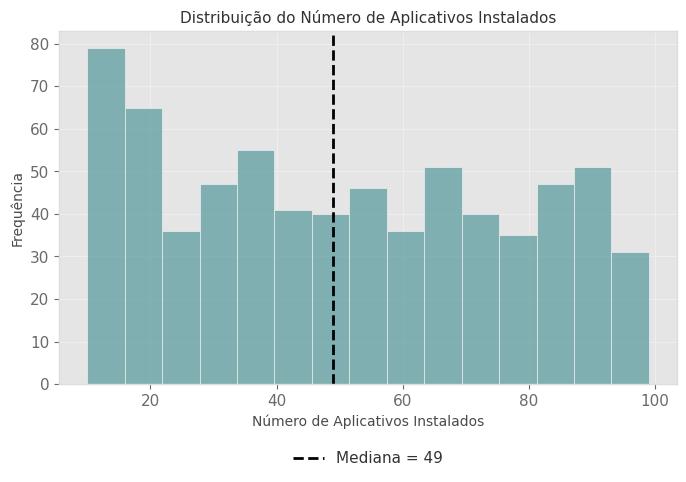

In [31]:
app_median = df['number of apps installed'].median()

fig, ax = plt.subplots(figsize = (7, 5))

sns.histplot(data = df, x = 'number of apps installed', bins = 15, color = paleta_cores[0])
ax.axvline(app_median, color = 'black', linestyle = '--', linewidth = 2, label = f'Mediana = {app_median:.0f}')

ax.set_title('Distribuição do Número de Aplicativos Instalados')
ax.set_xlabel('Número de Aplicativos Instalados')
ax.set_ylabel('Frequência')
ax.legend(   
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon = False)

plt.tight_layout()
plt.show()


O histograma mostra que o número de aplicativos instalados apresenta uma distribuição relativamente espalhada ao longo do intervalo observado, sem concentração exclusiva em uma única faixa. Ainda assim, percebe-se uma presença considerável de usuários com quantidades menores de aplicativos, especialmente nos intervalos iniciais do gráfico.

A linha vertical indica que a **mediana do número de aplicativos instalados é 49**, ou seja, metade dos usuários possui até 49 aplicativos instalados, enquanto a outra metade possui mais do que esse valor. Esse resultado sugere um nível intermediário de instalação de aplicativos no conjunto de dados, servindo como uma boa medida-resumo para representar o comportamento central da variável.

## Questão 7 — Padrões de uso com base no gênero

Nesta etapa, o objetivo é investigar se existem diferenças no comportamento de uso dos usuários com base no **gênero**. Para isso, serão analisadas variáveis como **sistema operacional**, **tempo de uso de aplicativos** e **tempo de tela ligada por dia**, comparando os grupos presentes no conjunto de dados.

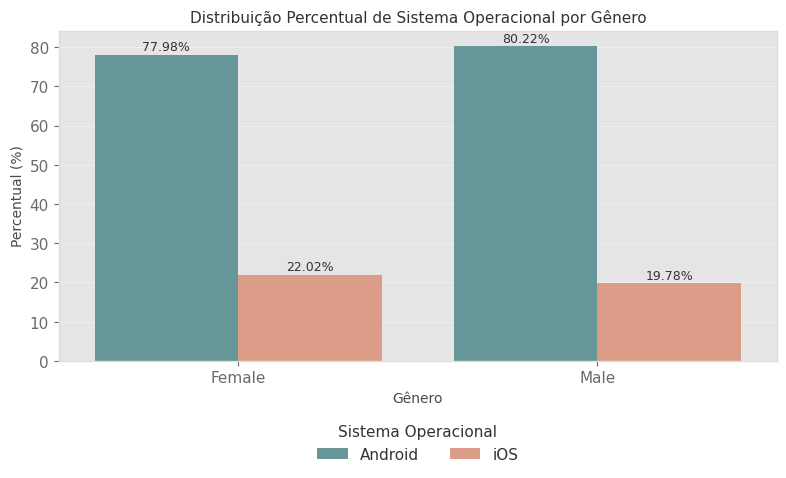

In [32]:
dist_so_genero = (
    df.groupby('gender')['operating system']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentual')
    .reset_index()
)
fig, ax = plt.subplots(figsize = (8, 5))
sns.barplot(
    data = dist_so_genero,
    x = 'gender',
    y = 'percentual',
    hue = 'operating system',
    ax = ax,
    palette=paleta_cores[:2]
)
for container in ax.containers:
    ax.bar_label(container, fmt = '%1.2f%%', padding = 1, fontsize = 9)
ax.set_title('Distribuição Percentual de Sistema Operacional por Gênero')
ax.set_xlabel('Gênero')
ax.set_ylabel('Percentual (%)')
ax.legend(
    title='Sistema Operacional',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon = False
)

plt.tight_layout()
plt.show()

A distribuição percentual dos sistemas operacionais por gênero mostra um padrão bastante semelhante entre os grupos. Em ambos os casos, o **Android** é claramente predominante, enquanto o **iOS** aparece com participação bem menor.

Dessa forma, não se observa, nesta análise, uma diferença expressiva entre os gêneros em relação ao sistema operacional utilizado. O comportamento é bastante parecido para **Female** e **Male**.

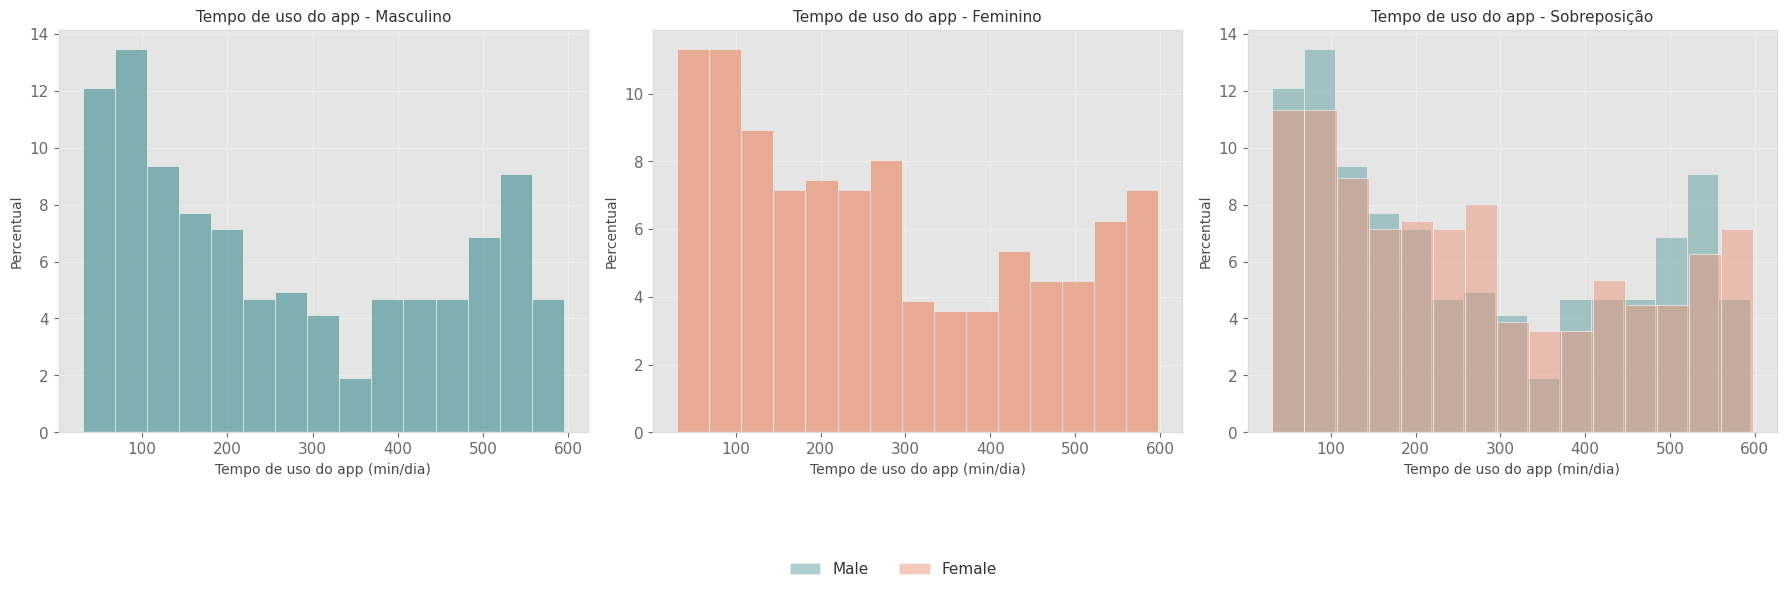

In [33]:
male_app = df[df['gender'] == 'Male']['app usage time (min/day)']
female_app = df[df['gender'] == 'Female']['app usage time (min/day)']

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

#Grafico 1
sns.histplot(data = male_app, bins = 15, stat = 'percent', color = paleta_cores[0], ax = ax[0])
ax[0].set_title('Tempo de uso do app - Masculino')
ax[0].set_xlabel('Tempo de uso do app (min/dia)')
ax[0].set_ylabel('Percentual')
#Grafico 2
sns.histplot(data = female_app, bins = 15, stat = 'percent', color = paleta_cores[1], ax =  ax[1])
ax[1].set_title('Tempo de uso do app - Feminino')
ax[1].set_xlabel('Tempo de uso do app (min/dia)')
ax[1].set_ylabel('Percentual')
#grafico 2
sns.histplot(data = male_app, bins = 15, stat = 'percent', color = paleta_cores[0], alpha = 0.5, label = 'Male', ax = ax[2])
sns.histplot(data = female_app, bins = 15, stat = 'percent', color = paleta_cores[1], alpha = 0.5, label = 'Female', ax = ax[2])
ax[2].set_title('Tempo de uso do app - Sobreposição')
ax[2].set_xlabel('Tempo de uso do app (min/dia)')
ax[2].set_ylabel('Percentual')

fig.legend(
    loc = 'upper center',
    bbox_to_anchor = (0.5, -0.11),
    ncol = 2,
    frameon = False
)
plt.tight_layout()
plt.show()

A comparação dos histogramas indica que o **tempo de uso de aplicativos** apresenta comportamento semelhante entre os gêneros **Male** e **Female**. As distribuições possuem formatos próximos e grande sobreposição ao longo das faixas observadas.

Assim, não se identificam diferenças visuais muito expressivas entre os grupos nessa variável, o que sugere um padrão de uso relativamente parecido entre os gêneros.

## Questão 8 — Relação entre idade e tempo de uso de aplicativos

Nesta etapa, o objetivo é investigar se existe relação entre a **idade dos usuários** e o **tempo de uso de aplicativos por dia**. Para isso, a análise será feita em dois momentos: primeiro, observando a **correlação linear** entre as variáveis; depois, segmentando os usuários em **faixas etárias** para comparar a média e a distribuição do tempo de uso entre os grupos.

In [34]:
corr_age_app = df['age'].corr(df['app usage time (min/day)'], method='pearson') * 100
print(f"Correlação entre idade e tempo de uso do app: {corr_age_app:.2f}")

Correlação entre idade e tempo de uso do app: 0.44


O coeficiente de Pearson encontrado foi de **0,44**, o que indica uma **associação linear fraca** entre a idade e o tempo de uso de aplicativos. Apesar de o valor ser positivo, ele não é alto o suficiente para caracterizar uma relação forte ou suficientemente consistente. Assim, isoladamente, a **idade não parece explicar de forma relevante o tempo de uso dos aplicativos** neste conjunto de dados.

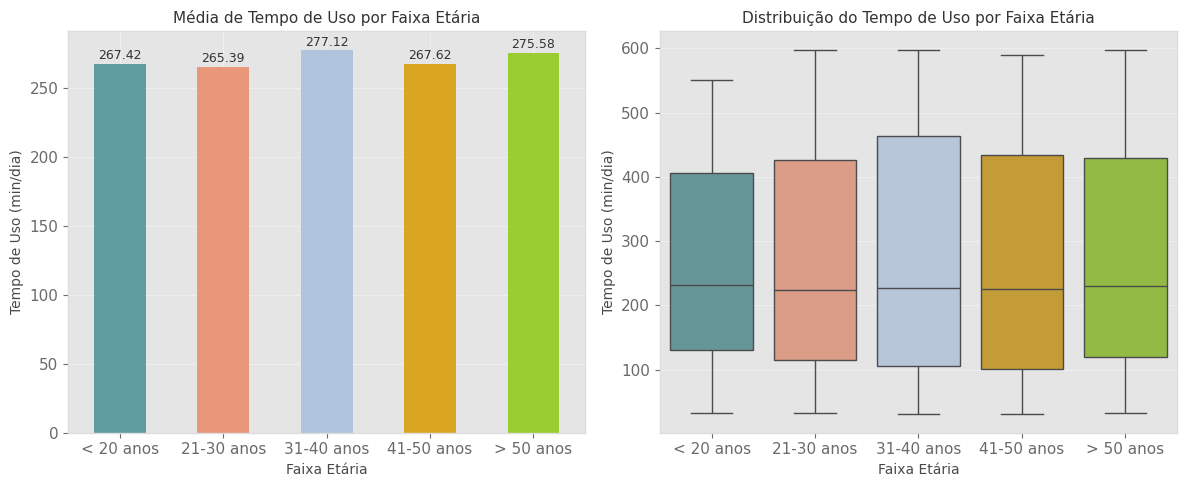

In [36]:
df['age_group'] = pd.cut(
    df['age'],
    bins = [0, 20, 30, 40, 50, 100],
    labels = ['< 20 anos','21-30 anos','31-40 anos','41-50 anos','> 50 anos']
)

media_group_use = df.groupby('age_group', observed = False)['app usage time (min/day)'].mean().round(2)

fig, ax = plt.subplots(1, 2, figsize = (12, 5))

media_group_use.plot(
    kind = 'bar',
    color = paleta_cores[:5],
    ax = ax[0]
)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.2f', fontsize = 9, padding = 1)

ax[0].set_title('Média de Tempo de Uso por Faixa Etária')
ax[0].set_xlabel('Faixa Etária')
ax[0].set_ylabel('Tempo de Uso (min/dia)')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 0)

sns.boxplot(
    data = df,
    x = 'age_group',
    y = 'app usage time (min/day)',
    ax = ax[1],
    palette = paleta_cores[:5],
    hue='age_group'
    
)
ax[1].set_title('Distribuição do Tempo de Uso por Faixa Etária')
ax[1].set_xlabel('Faixa Etária')
ax[1].set_ylabel('Tempo de Uso (min/dia)')


plt.tight_layout()
plt.show()

Ao segmentar os usuários por **faixa etária**, observa-se que o **tempo médio de uso de aplicativos** permaneceu relativamente próximo entre os grupos, variando entre aproximadamente **265 e 277 minutos por dia**. A faixa de **31 a 40 anos** apresentou a maior média (**277,12 min/dia**), enquanto a faixa de **21 a 30 anos** apresentou a menor (**265,39 min/dia**), o que indica diferenças discretas entre as categorias.

O boxplot complementa essa análise ao mostrar que as distribuições das faixas etárias são bastante semelhantes, com **medianas próximas** e **dispersões parecidas**. Assim, embora exista uma **correlação positiva moderada** entre idade e tempo de uso, a análise por grupos sugere que esse aumento ocorre de forma **suave**, sem mudanças muito bruscas entre uma faixa etária e outra.

# Questao 9

## Questão 9 — Sistema operacional mais comum e variação por faixa etária

Nesta etapa, o objetivo é identificar qual é o **sistema operacional mais comum** entre os usuários do conjunto de dados e verificar como essa distribuição se comporta nas **faixas etárias** criadas anteriormente. Para isso, será analisada tanto a distribuição geral entre **Android** e **iOS** quanto a distribuição percentual desses sistemas dentro de cada grupo etário.

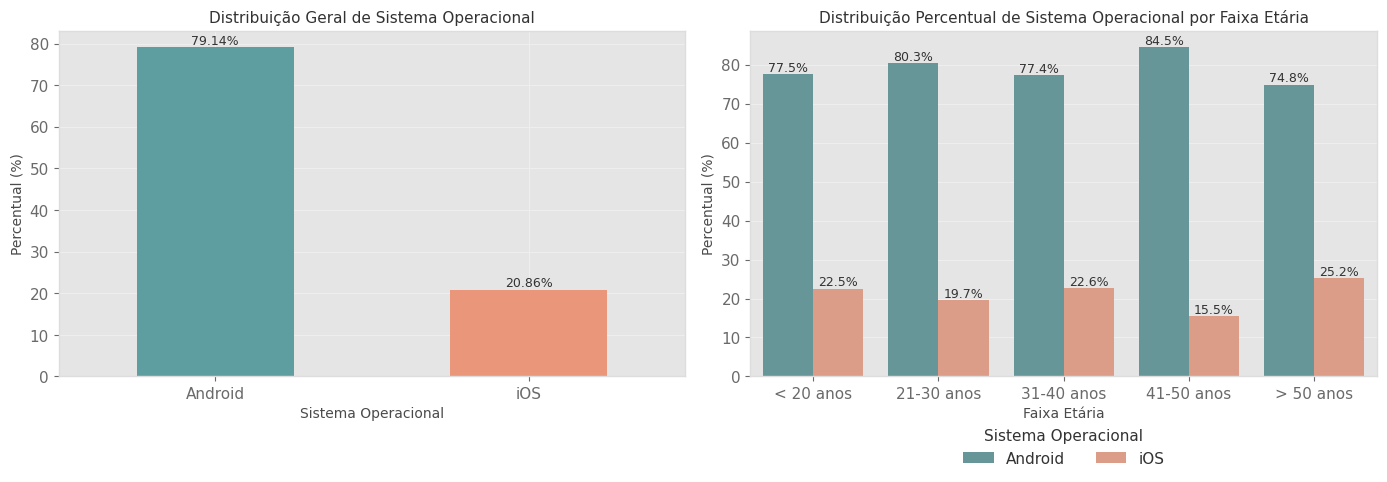

In [ ]:
so_total_faixa = df['operating system'].value_counts(normalize = True).mul(100).round(2)

dist_so_faixa = (
    df.groupby('age_group', observed = False)['operating system']
    .value_counts(normalize = True)
    .mul(100)
    .rename('percentual')
    .reset_index()
)

fig, ax = plt.subplots(1, 2, figsize = (14, 5))

so_total_faixa.plot(
    kind = 'bar',
    color = paleta_cores[:2],
    ax = ax[0]
)

for container in ax[0].containers:
    ax[0].bar_label(container, fmt = '%1.2f%%', fontsize = 9)

ax[0].set_title('Distribuição Geral de Sistema Operacional')
ax[0].set_xlabel('Sistema Operacional')
ax[0].set_ylabel('Percentual (%)')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 0)

sns.barplot(
    data = dist_so_faixa,
    x = 'age_group',
    y = 'percentual',
    hue = 'operating system',
    ax = ax[1],
    palette = paleta_cores[:2]

)

for container in ax[1].containers:
    ax[1].bar_label(container, fmt = '%1.1f%%', fontsize = 9)

ax[1].set_title('Distribuição Percentual de Sistema Operacional por Faixa Etária')
ax[1].set_xlabel('Faixa Etária')
ax[1].set_ylabel('Percentual (%)')
ax[1].legend(
    title='Sistema Operacional',
    loc = 'upper center',
    bbox_to_anchor = (0.5, -0.11),
    ncol = 2,
    frameon = False
    )

plt.tight_layout()
plt.show()

A análise geral mostra que o **Android** é, de forma ampla, o sistema operacional mais utilizado no conjunto de dados, representando **79,14%** dos usuários, enquanto o **iOS** corresponde a **20,86%**. Isso indica uma predominância clara de dispositivos Android na amostra analisada.

Ao observar a distribuição por **faixa etária**, percebe-se que esse padrão se mantém em todos os grupos, ou seja, o Android continua sendo o sistema mais frequente independentemente da idade. A maior participação do Android foi registrada na faixa de **41 a 50 anos** (**84,5%**), enquanto a menor ocorreu entre usuários com **mais de 50 anos** (**74,8%**). Já o iOS apresentou comportamento complementar, com maior presença relativa na faixa de **mais de 50 anos** (**25,2%**) e menor participação entre **41 e 50 anos** (**15,5%**).

Dessa forma, os resultados sugerem que, embora existam pequenas variações entre as faixas etárias, **não há mudança no padrão predominante de sistema operacional**, já que o Android lidera em todos os grupos analisados.

## Questão 10 — Médias por classe de comportamento e distribuição de gênero

Nesta etapa, o objetivo é analisar como as diferentes **classes de comportamento** se distinguem em relação à **média de tempo de uso de aplicativos**, **tempo de tela ligada** e **idade**. Além disso, será verificado se a **distribuição de gênero** se mantém semelhante entre as classes ou se existem diferenças relevantes na composição de cada grupo.

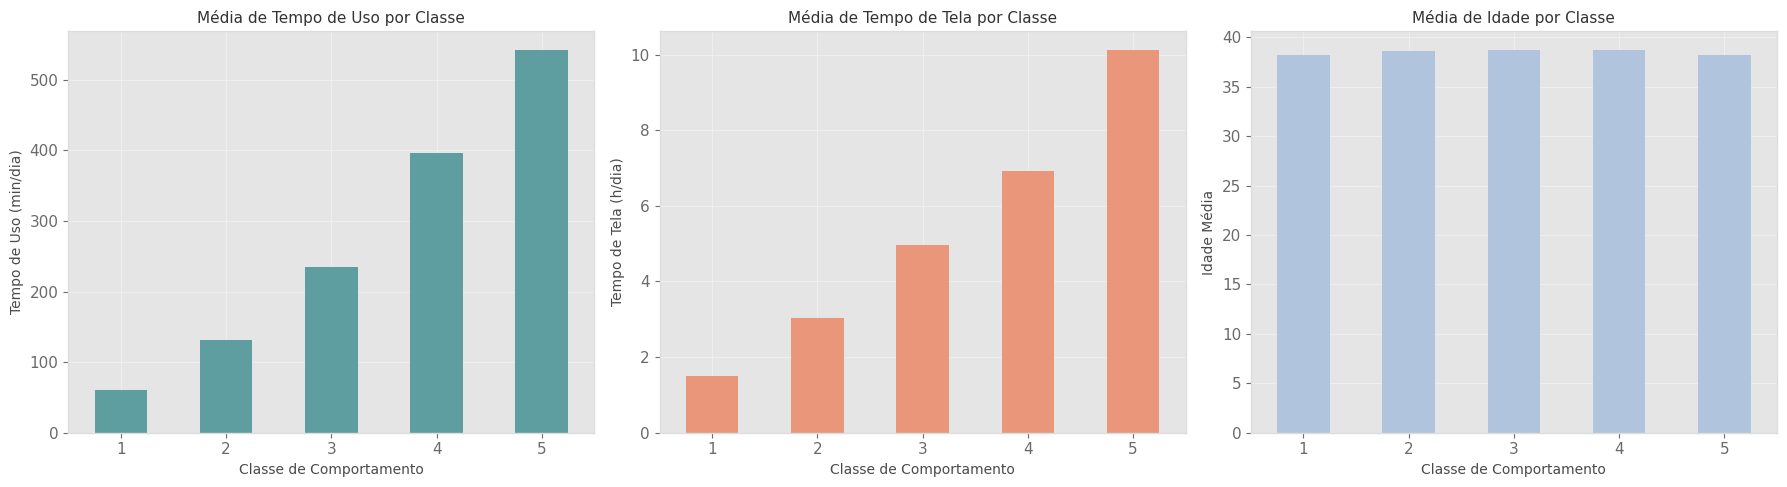

In [52]:
media_classes = df.groupby('user behavior class')[[
    'app usage time (min/day)',
    'screen on time (hours/day)',
    'age'
]].mean().round(2)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

config_graficos = [
    ('app usage time (min/day)', 'Média de Tempo de Uso por Classe', 'Tempo de Uso (min/dia)', paleta_cores[0]),
    ('screen on time (hours/day)', 'Média de Tempo de Tela por Classe', 'Tempo de Tela (h/dia)', paleta_cores[1]),
    ('age', 'Média de Idade por Classe', 'Idade Média', paleta_cores[2])
]

for eixo, (coluna, titulo, ylabel, cor) in zip(ax, config_graficos):
    media_classes[coluna].plot(
        kind='bar',
        color=cor,
        ax=eixo
    )
    eixo.set_title(titulo)
    eixo.set_xlabel('Classe de Comportamento')
    eixo.set_ylabel(ylabel)
    eixo.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Ao observar as médias por **classe de comportamento**, fica evidente um crescimento progressivo tanto no **tempo de uso de aplicativos** quanto no **tempo de tela ligada** à medida que a classe aumenta. A classe **1** apresenta os menores valores médios, enquanto a classe **5** concentra os maiores, o que sugere que a classificação está fortemente associada ao nível de uso dos dispositivos.

Por outro lado, a **idade média** se manteve praticamente estável entre todas as classes, com valores muito próximos, em torno de **38 anos**. Isso indica que, diferentemente das métricas de uso, a idade **não parece ser um fator determinante** para diferenciar as classes de comportamento neste conjunto de dados.

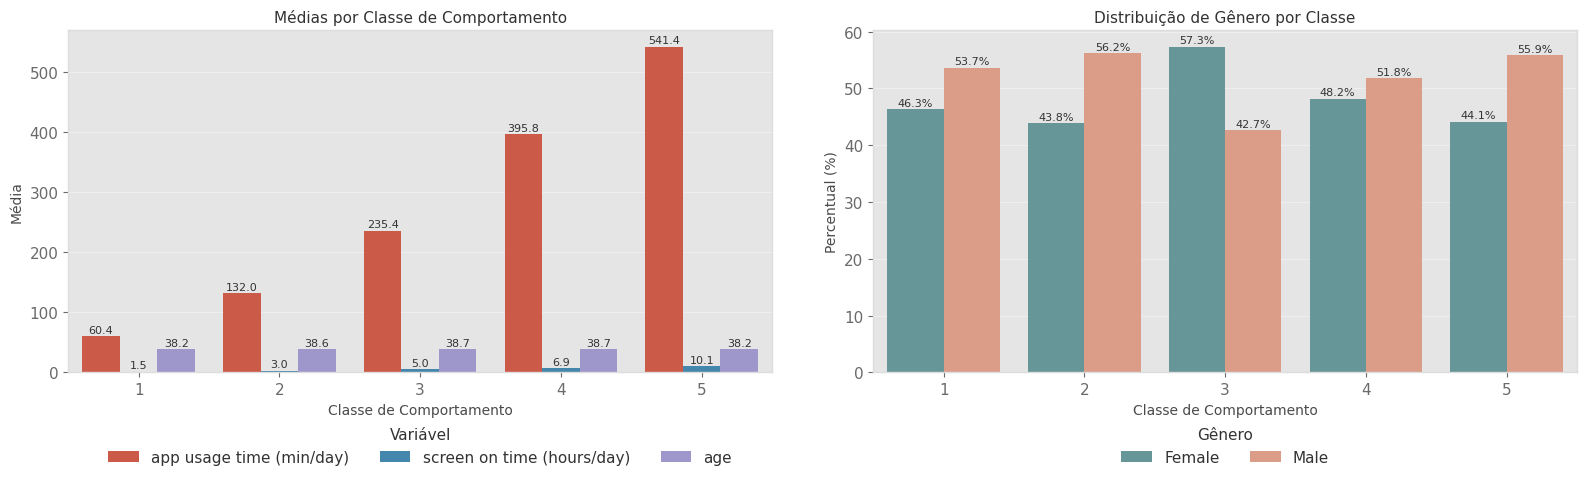

In [ ]:
media_classes_plot = media_classes.reset_index().melt(
    id_vars='user behavior class',
    var_name='variavel',
    value_name='media'
)

genero_classes = pd.crosstab(
    df['user behavior class'],
    df['gender'],
    normalize='index'
).mul(100).round(2)

genero_classes_plot = genero_classes.reset_index().melt(
    id_vars='user behavior class',
    var_name='gender',
    value_name='percentual'
)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=media_classes_plot,
    x='user behavior class',
    y='media',
    hue='variavel',
    ax=ax[0]
)

for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.1f', fontsize=8, padding=1)

ax[0].set_title('Médias por Classe de Comportamento')
ax[0].set_xlabel('Classe de Comportamento')
ax[0].set_ylabel('Média')
ax[0].legend(
    title='Variável',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)

sns.barplot(
    data=genero_classes_plot,
    x='user behavior class',
    y='percentual',
    hue='gender',
    palette=paleta_cores[:2],
    ax=ax[1]
)

for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.1f%%', fontsize=8, padding=1)

ax[1].set_title('Distribuição de Gênero por Classe')
ax[1].set_xlabel('Classe de Comportamento')
ax[1].set_ylabel('Percentual (%)')
ax[1].legend(
    title='Gênero',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

A visualização conjunta das médias por classe reforça que as variáveis **tempo de uso de aplicativos** e **tempo de tela** aumentam de forma clara conforme se avança das classes mais baixas para as mais altas. Já a variável **idade** permanece praticamente constante, confirmando que a principal distinção entre as classes está no **padrão de uso do dispositivo**, e não no perfil etário dos usuários.

Em relação à **distribuição de gênero**, os resultados mostram que ela **não é exatamente a mesma** em todas as classes. Há variações na proporção de homens e mulheres entre os grupos, embora sem uma diferença extremamente acentuada na maior parte deles. A classe **3** foi a única em que o grupo **feminino** apareceu em maior proporção (**57,3%**), enquanto nas demais classes houve predominância masculina, com destaque para as classes **2** (**56,2%**) e **5** (**55,9%**).

Dessa forma, pode-se concluir que as **classes de comportamento** são diferenciadas principalmente pelas **intensidades de uso e de tempo de tela**, enquanto a **idade média varia muito pouco** entre elas. Já o **gênero** apresenta pequenas oscilações de composição entre as classes, mas sem alterar o padrão geral de forma muito brusca.